In [70]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [72]:
path = '../survey_design/telescope_and_science_metrics/'

In [73]:
survey_design_dark = load(path + 'survey_design_Dark_lbg_only.pkl')
survey_design_dark_qso = load(path + 'survey_design_Dark_qso_only.pkl')
survey_design_dark_one_tracer = load(path + 'survey_design_Dark_lbg_only_onetracer_approach.pkl')

LBGu = 5180.838323353293
LBGg = 2555.0898203592815
LBGr = 497.0059880239521


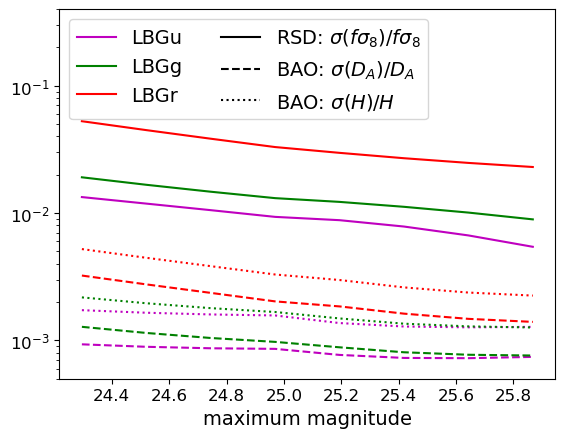

In [74]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark
    i=3
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_rsd_eff'])
    plt.plot(x, y, '-', label = tracer,
                 color = color, 
                 marker='', )
    
    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'])
    plt.plot(x, y, '--', #label = tracer,
                 color = color, 
                 marker='', )

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_H_eff'])
    plt.plot(x, y, ls=':',
                 color = color, 
                 )

plt.ylim(0.0005, 0.4)
plt.yscale('log')
#plt.ylabel(r'$\sigma(f_{\rm NL})$', fontsize=15)
plt.xlabel(r'maximum magnitude', fontsize=14)
plt.plot([], [], '-k', label = r'RSD: $\sigma(f\sigma_8)/f\sigma_8$')
plt.plot([], [], '--k', label = r'BAO: $\sigma(D_A)/D_A$')
plt.plot([], [], ':k', label = r'BAO: $\sigma(H)/H$')
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=14, ncols=2, loc='upper left')

In [33]:

sigma_omega_m = 0.0012
h_fid         = 0.677
sigma_H0      = 100.0 * 0.0054

F_prior = np.diag([
    1 / 1e6,                                  # w0  — essentially flat
    1 / 1e6,                                  # wa  — essentially flat
    (h_fid**2 / sigma_omega_m)**2,            # Omega_m, from omega_m prior
    1 / sigma_H0**2,                          # H0
])
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark

    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'])

    survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'] = []
    survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'] = []
    survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'] = []
    err_w0 = []
    err_wa = []
    for i in range(len(survey['per_tracer_forecasts'][tracer+'_zeff_Da'])):
        zeff = survey['per_tracer_forecasts'][tracer+'_zeff_Da'][i]
        sigma_Da_eff = survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'][i]
        sigma_H_eff = survey['per_tracer_forecasts'][tracer+'_sigma_H_eff'][i]
        
        Fisher_mat_w0wa = fisher_matrix_bao_SuEisenstein.Fisher_mat_BAO_cosmo_params(zeff, sigma_Da_eff, sigma_H_eff, cosmo,  param_names=('w0', 'wa', 'Omega_m', 'H0'), rel_step=1e-2)
        survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'].append(Fisher_mat_w0wa)
        err_w0.append(np.linalg.inv(Fisher_mat_w0wa + F_prior).diagonal()[0]**.5)
        err_wa.append(np.linalg.inv(Fisher_mat_w0wa + F_prior).diagonal()[1]**.5)
    survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'] = np.array(err_w0)
    survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'] = np.array(err_wa)

Text(0.5, 0, 'maximum magnitude')

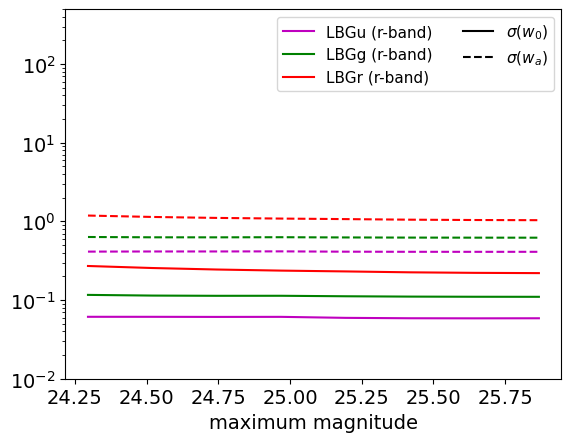

In [39]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'])
    mask_color = np.array(survey['config_survey']['tracers'])==tracer
    color = np.array(survey['config_survey']['color'])[mask_color][0]
    mask_index_tracer_in_survey = survey["config_survey"]['tracers'] == tracer
    plt.plot(np.array(x)[y < 1000], np.array(y)[y < 1000],
                 color = color, 
                 marker='',label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][mask_index_tracer_in_survey]}-band)')

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'])
    plt.plot(np.array(x)[y < 1000], np.array(y)[y < 1000],
                 color = color, ls='--',
                 marker='')

    #plt.xlim(0, 1.3)
    plt.ylim(0.01, 500)
plt.xlabel(r'redshift bin', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.yscale('log')
plt.plot([], [], '-k', label = r'$\sigma(w_0)$')
plt.plot([], [], '--k', label = r'$\sigma(w_a)$')
plt.legend(fontsize=11, ncols=2)
plt.xlabel(r'maximum magnitude', fontsize=14)

LBGg = 1771.8562874251495
LBGr = 706.5868263473055
LBGu = 2094.0119760479047
LBGu = 2864.670658682635
LBGu = 3879.0419161676655
LBGu = 5180.838323353293
LBGu = 6764.071856287424
LBGu = 8694.610778443115
LBGu = 10822.754491017968
LBGu = 13396.407185628745



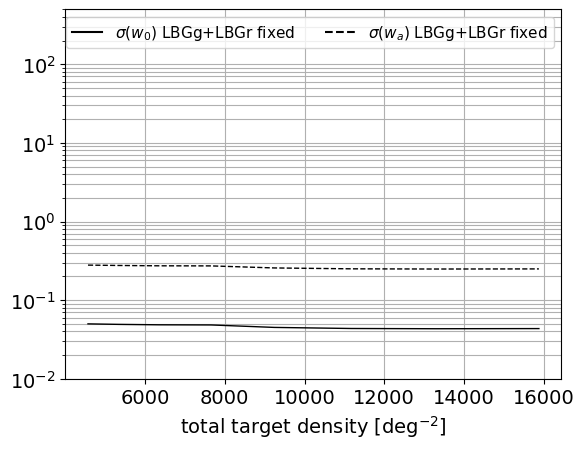

In [66]:

x = survey_design_dark['config_survey']['LBGu_target_density']


def plot(index, color = None):
    n=0
    Fisher_tot = 0
    for k, tracer in enumerate(['LBGg', 'LBGr']):
        
            n+=survey['config_survey'][tracer+'_target_density'][index[k]]
            print(tracer, '=', survey['config_survey'][tracer+'_target_density'][index[k]])
            Fisher_tot += survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'][index[k]]
    
    err_w0 = []
    err_wa = []
    for i in range(len(x)):
        Fisher_tot_x = Fisher_tot + survey['per_tracer_forecasts']['LBGu_Fisher_mat_wOwa_eff'][i]
        print('LBGu', '=', survey['config_survey']['LBGu_target_density'][i])
        err_w0.append(np.linalg.inv(Fisher_tot_x  + F_prior).diagonal()[0]**.5)
        err_wa.append(np.linalg.inv(Fisher_tot_x + F_prior).diagonal()[1]**.5)
    plt.plot(n+x, err_w0, '-', color=color[0],lw=1)
    plt.plot(n+x, err_wa, '--', color=color[1], lw=1)

plot([2,4], color = ['k', 'k'])
print()
#plot([2,2], color = ['orange', 'red'])
#plot([3,4])
plt.plot([], [], '-k', label = r'$\sigma(w_0)$ LBGg+LBGr fixed')
plt.plot([], [], '--k', label = r'$\sigma(w_a)$ LBGg+LBGr fixed')
plt.xlabel(r'total target density [deg$^{-2}$]', fontsize=14)
#plt.yscale('log')
plt.xlabel(r'total target density [deg$^{-2}$]', fontsize=14)
plt.yscale('log')
plt.ylim(0.01, 500)
#plt.xlim(9000, 30000, 5e4)
plt.grid(which='both')
plt.legend(fontsize=11, loc='upper right', ncols=2)
plt.tick_params(axis='both', labelsize=14)

In [68]:
def plot_vs_ratio(vary_tracer, denom_tracer, fixed, color=None, density_source=None, lw=1, ls = None, marker = None):
    """
    vary_tracer  : tracer whose density array is scanned (e.g. 'LBGg' or 'LBGr')
    denom_tracer : tracer used as the ratio denominator (e.g. 'LBGu')
    fixed        : dict {tracer_name: index} for the tracers held fixed
    color        : [color_w0, color_wa]
    density_source: dict to pull the varying density array from (defaults to `survey`)
    """
    density_source = density_source or survey
    dens_array = density_source['config_survey'][vary_tracer + '_target_density']

    Fisher_fixed = 0
    n_denom = None
    for tracer, idx in fixed.items():
        Fisher_fixed += survey['per_tracer_forecasts'][tracer + '_Fisher_mat_wOwa_eff'][idx]
        n_val = survey['config_survey'][tracer + '_target_density'][idx]
        if tracer == denom_tracer:
            n_denom = n_val

    if n_denom is None:
        raise ValueError(f"{denom_tracer} must be one of the fixed tracers")

    ratio, err_w0, err_wa = [], [], []
    for i in range(len(dens_array)):
        Fisher_tot = Fisher_fixed + survey['per_tracer_forecasts'][vary_tracer + '_Fisher_mat_wOwa_eff'][i]
        cov = np.linalg.inv(Fisher_tot  + F_prior)
        err_w0.append(cov.diagonal()[0]**0.5)
        err_wa.append(cov.diagonal()[1]**0.5)
        ratio.append(dens_array[i] / n_denom)

    plt.plot(ratio, err_w0,  color=color[0], lw=lw, ls=ls[0], marker=marker[0], markersize=3)
    plt.plot(ratio, err_wa, color=color[1], lw=lw, ls=ls[1], marker=marker[0], markersize=3)
    plt.xlabel(r'fraction $N_{\rm LBGx}/N_{\rm LBGu}$', fontsize=14)
    plt.yscale('log')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim(0.01, 500)
#plt.xlim(9000, 30000, 5e4)
    plt.grid(which='both')
    plt.legend(fontsize=11, loc='upper right', ncols=2)
    plt.tick_params(axis='both', labelsize=14)
    
    return ratio, err_w0, err_wa

/tmp/ipykernel_3487930/2909747111.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_r = cm.get_cmap('cool')
/tmp/ipykernel_3487930/2909747111.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_k = cm.get_cmap('cool')  # or use a single-hue cmap, e.g. 'binary'/'bone'
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that ar

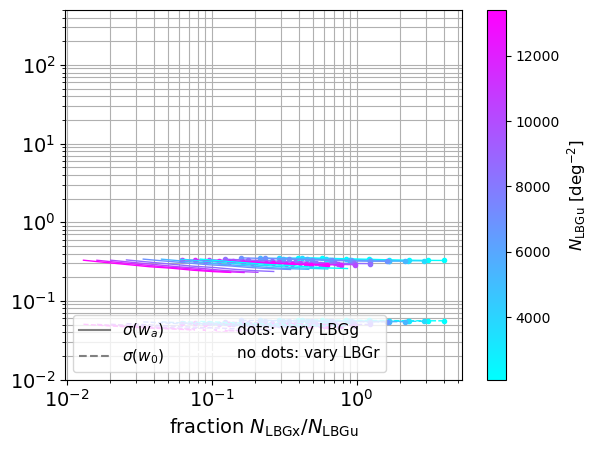

In [69]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

n_u = survey['config_survey']['LBGu_target_density']
N = len(n_u)

cmap_r = cm.get_cmap('cool')
cmap_k = cm.get_cmap('cool')  # or use a single-hue cmap, e.g. 'binary'/'bone'
norm = mcolors.Normalize(vmin=0, vmax=N - 1)

for i in range(len(survey['config_survey']['LBGu_target_density'])):

    color_r = cmap_r(norm(i))
    color_k = cmap_k(norm(i))
    z=plot_vs_ratio('LBGg', 'LBGu', {'LBGu': i,}, color=[color_r, color_k], density_source=None, lw=1, ls = ['--', '-'], marker = ['o','o'])

cmap_r = cm.get_cmap('cool')
cmap_k = cm.get_cmap('cool')  # or use a single-hue cmap, e.g. 'binary'/'bone'
norm = mcolors.Normalize(vmin=0, vmax=N - 1)
for i in range(len(survey['config_survey']['LBGu_target_density'])):

    color_r = cmap_r(norm(i))
    color_k = cmap_k(norm(i))
    z=plot_vs_ratio('LBGr', 'LBGu', {'LBGu': i,}, color=[color_r, color_k], density_source=None, lw=1, ls = ['--', '-'], marker = ['',''])

plt.plot([], [], '-', color='gray', label=r'$\sigma(w_a)$')
plt.plot([], [], '--',  color='gray', label=r'$\sigma(w_0)$')
plt.plot([], [], '--w', label = 'dots: vary LBGg')
plt.plot([], [], '--w', label = 'no dots: vary LBGr')
plt.grid(which='both')
plt.legend(fontsize=11, ncols=2, loc='lower left')
plt.tick_params(axis='both', labelsize=14)

sm = cm.ScalarMappable(cmap='cool', norm=mcolors.Normalize(vmin=n_u[0], vmax=n_u[-1]))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label(r'$N_{\rm LBGu}$ [deg$^{-2}$]', fontsize=12)

In [55]:
survey_design_dark['per_tracer_forecasts'].keys()

dict_keys(['LBGu_mag_max_eval', 'LBGu_list_zbin_fnl', 'LBGu_zeff_fnl', 'LBGu_list_sigma_fnl', 'LBGu_sigma_fnl_eff', 'LBGu_list_zbin_Da', 'LBGu_zeff_Da', 'LBGu_list_sigma_Da', 'LBGu_sigma_Da_eff', 'LBGu_list_zbin_H', 'LBGu_zeff_H', 'LBGu_list_sigma_H', 'LBGu_sigma_H_eff', 'LBGu_list_zbin_Mnu', 'LBGu_zeff_Mnu', 'LBGu_list_sigma_Mnu', 'LBGu_sigma_Mnu_eff', 'LBGu_list_zbin_rsd', 'LBGu_zeff_rsd', 'LBGu_list_sigma_rsd', 'LBGu_sigma_rsd_eff', 'LBGg_mag_max_eval', 'LBGg_list_zbin_fnl', 'LBGg_zeff_fnl', 'LBGg_list_sigma_fnl', 'LBGg_sigma_fnl_eff', 'LBGg_list_zbin_Da', 'LBGg_zeff_Da', 'LBGg_list_sigma_Da', 'LBGg_sigma_Da_eff', 'LBGg_list_zbin_H', 'LBGg_zeff_H', 'LBGg_list_sigma_H', 'LBGg_sigma_H_eff', 'LBGg_list_zbin_Mnu', 'LBGg_zeff_Mnu', 'LBGg_list_sigma_Mnu', 'LBGg_sigma_Mnu_eff', 'LBGg_list_zbin_rsd', 'LBGg_zeff_rsd', 'LBGg_list_sigma_rsd', 'LBGg_sigma_rsd_eff', 'LBGr_mag_max_eval', 'LBGr_list_zbin_fnl', 'LBGr_zeff_fnl', 'LBGr_list_sigma_fnl', 'LBGr_sigma_fnl_eff', 'LBGr_list_zbin_Da', 'LBGr

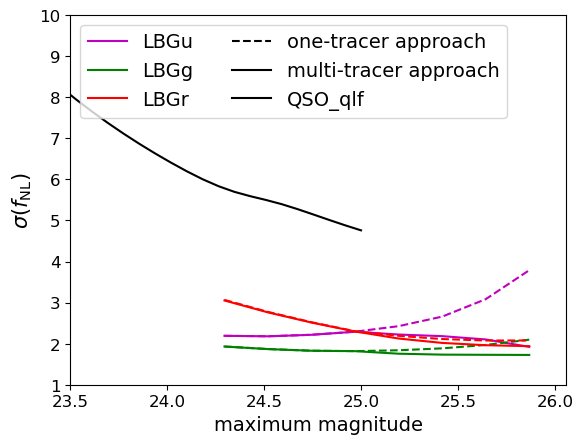

In [64]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_fnl_eff'])
    plt.plot(x, y,  label = tracer,
                 color = color, 
                 marker='', )

    x, y = survey_design_dark_one_tracer['config_survey'][tracer+'_mag_centers'], np.array(survey_design_dark_one_tracer ['per_tracer_forecasts'][tracer+'_sigma_fnl_eff'])
    plt.plot(x, y, ls='--',
                 color = color, 
                 )

    #plt.xlim(2, 6)
    plt.ylim(1, 5)
plt.ylabel(r'$\sigma(f_{\rm NL})$', fontsize=15)
plt.xlabel(r'maximum magnitude', fontsize=14)
plt.plot([], [], '--k', label = 'one-tracer approach')
plt.plot([], [], '-k', label = 'multi-tracer approach')

plt.tick_params(axis='both', labelsize=12)

survey = survey_design_dark_qso

mask_color = np.array(survey['config_survey']['tracers'])=='QSO_qlf'

color = np.array(survey['config_survey']['color'])[mask_color][0]

x, y = survey['config_survey']['QSO_qlf_mag_centers'], np.array(survey['per_tracer_forecasts']['QSO_qlf_sigma_fnl_eff'])
plt.plot(x, y,  label = 'QSO_qlf',
             color = 'k', 
             marker='', )


plt.ylim(1, 10)
plt.xlim(23.5)

plt.legend(fontsize=14, ncols=2, loc='upper left')

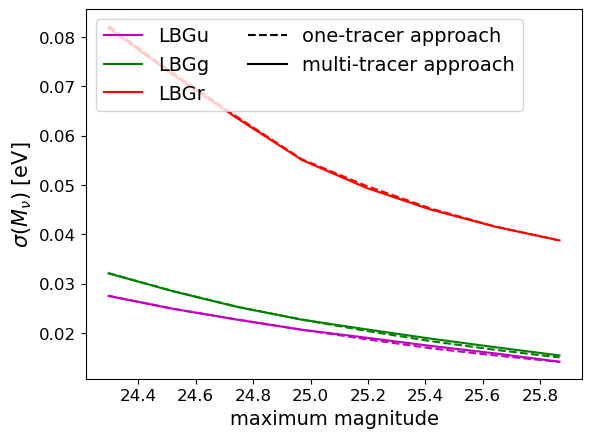

In [65]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Mnu_eff'])
    plt.plot(x, y,  label = tracer,
                 color = color, 
                 marker='', )

    x, y = survey_design_dark_one_tracer['config_survey'][tracer+'_mag_centers'], np.array(survey_design_dark_one_tracer ['per_tracer_forecasts'][tracer+'_sigma_Mnu_eff'])
    plt.plot(x, y, ls='--',
                 color = color, 
                 )

    #plt.xlim(2, 6)
    #plt.ylim(1, 10)
plt.ylabel(r'$\sigma(M_\nu)$ [eV]', fontsize=15)
plt.xlabel(r'maximum magnitude', fontsize=14)
plt.plot([], [], '--k', label = 'one-tracer approach')
plt.plot([], [], '-k', label = 'multi-tracer approach')

plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=14, ncols=2, loc='upper left')